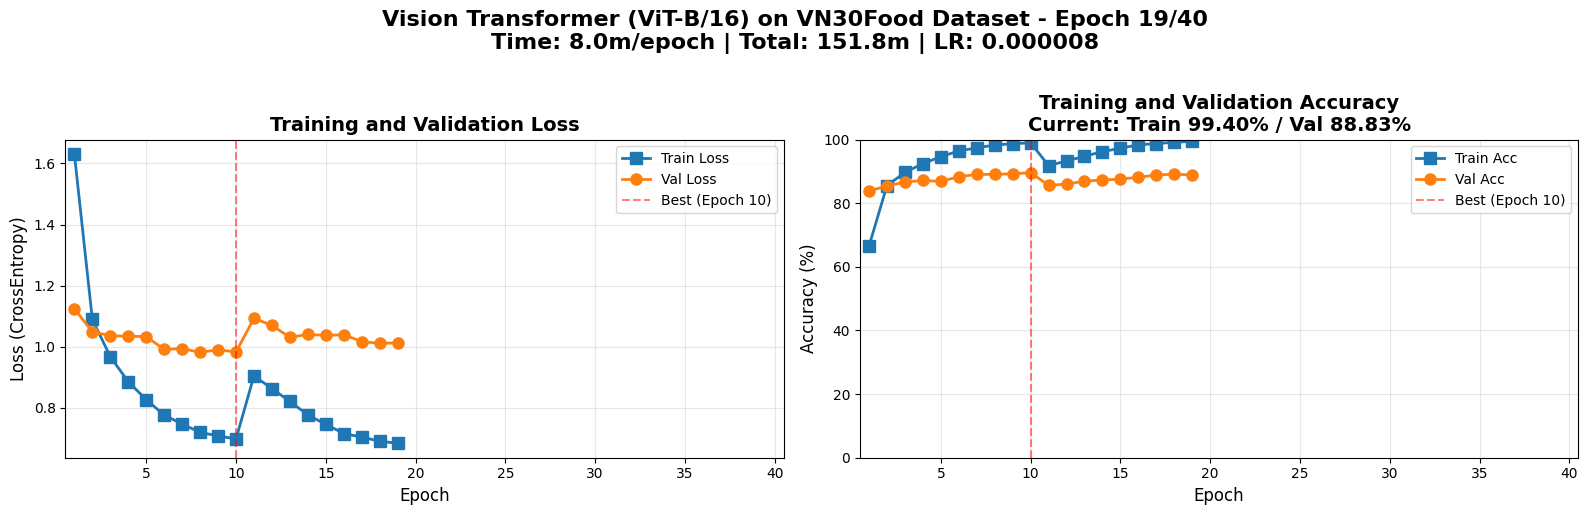


Epoch 19/40 Summary:
Train Loss: 0.6837 | Train Acc: 99.40%
Val Loss:   1.0124 | Val Acc:   88.83%
Best Val Loss: 0.9813 | Best Val Acc: 89.61% at Epoch 10
Learning Rate: 0.000008
Time: 8.0m | Total Time: 151.8m

Epoch 20/40 [==============================] - 274/274 - loss: 0.6816 - acc: 0.9945
⚠ Early stopping triggered at epoch 20
   No improvement for 10 epochs

TRAINING COMPLETED!
Best validation loss: 0.9813
Best validation accuracy: 89.61% at epoch 10
Final train accuracy: 0.00%
Final validation accuracy: 0.00%
Total training time: 159.81 minutes

Final model saved to: /kaggle/working/vit_vn30food_final_model.pth
Best model saved to: /kaggle/working/best_vit_vn30food_model.pth

FINAL TRAINING RESULTS


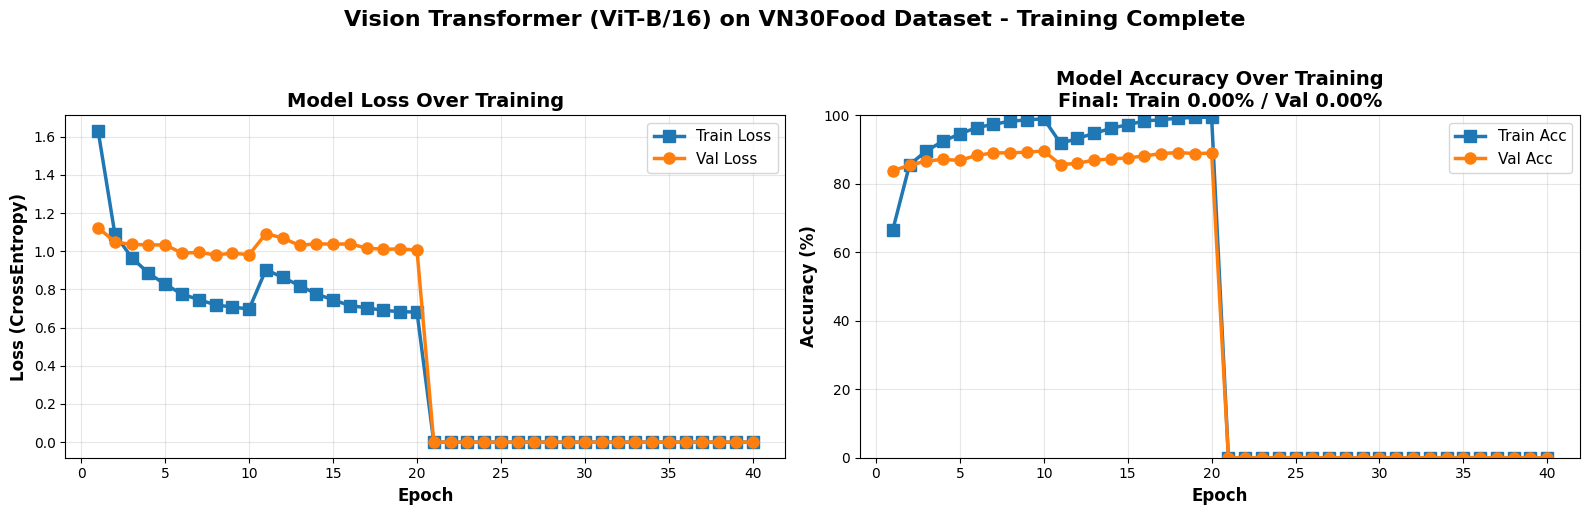


Training history plot saved to: /kaggle/working/vit_training_history.png

EVALUATION ON VALIDATION SET


RuntimeError: Error(s) in loading state_dict for VisionTransformer:
	Unexpected key(s) in state_dict: "heads.head.4.weight", "heads.head.4.bias". 
	size mismatch for heads.head.1.weight: copying a param with shape torch.Size([512, 768]) from checkpoint, the shape in current model is torch.Size([30, 768]).
	size mismatch for heads.head.1.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([30]).

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os
import unicodedata
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import numpy as np
import random
import sys
import time
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

os.environ["WANDB_DISABLED"] = "true"

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# ============================================================
# PATHS CONFIGURATION - VN30FOOD
# ============================================================
VNF_DIR = "/kaggle/input/dataset-for-nutridish-project/Model_Training/datasets/30vnfoods/Images"
BASE_DIR = os.path.dirname(VNF_DIR)

# Verify paths exist
assert os.path.isdir(VNF_DIR), f"Images folder not found: {VNF_DIR}"

# Read Vietnamese food classes
with open(os.path.join(BASE_DIR, "class_mapping.json")) as f:
    vn_classes_map = json.load(f)

vn_classes = list(vn_classes_map.keys())
NUM_CLASSES = len(vn_classes)
CLASS_TO_INDEX = {c: i for i, c in enumerate(vn_classes)}
print(f"\nTotal Vietnamese food classes: {NUM_CLASSES}")
print(f"Classes: {vn_classes[:5]}... (showing first 5)")

# ============================================================
# HELPER FUNCTIONS
# ============================================================
def normalize_name(name):
    """Remove accents and normalize class names"""
    name = unicodedata.normalize("NFD", name)
    name = "".join(ch for ch in name if unicodedata.category(ch) != "Mn")
    name = name.strip().lower().replace(" ", "_")
    return name

def list_images(base_dir, subset, vn_classes):
    """List all valid images in Vietnamese food dataset"""
    paths, labels = [], []
    subset_dir = os.path.join(base_dir, subset)
    
    if not os.path.exists(subset_dir):
        print(f"⚠ Directory not found: {subset_dir}")
        return paths, labels
    
    print(f"\nScanning {subset} directory...")
    for class_name in os.listdir(subset_dir):
        class_dir = os.path.join(subset_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        
        class_key = normalize_name(class_name)
        if class_key not in vn_classes:
            print(f"⚠ Skipped: '{class_name}' → '{class_key}' not in mapping.json")
            continue
        
        class_label = vn_classes.index(class_key)
        
        img_count = 0
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                full_path = os.path.join(class_dir, fname)
                paths.append(full_path)
                labels.append(class_label)
                img_count += 1
        
        print(f"  ✓ {class_name}: {img_count} images")
    
    return paths, labels

# ============================================================
# BUILD DATASET
# ============================================================
print("\n" + "="*60)
print("BUILDING VN30FOOD DATASET")
print("="*60)

train_paths, train_labels = list_images(VNF_DIR, "Train", vn_classes)
val_paths, val_labels = list_images(VNF_DIR, "Validate", vn_classes)
test_paths, test_labels = list_images(VNF_DIR, "Test", vn_classes)

print(f"\n✓ Train entries: {len(train_paths)}")
print(f"✓ Validation entries: {len(val_paths)}")
print(f"✓ Test entries: {len(test_paths)}")

# ============================================================
# CUSTOM DATASET CLASS
# ============================================================
class VNFoodDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        """
        Args:
            image_paths: List of image file paths
            labels: List of corresponding labels
            transform: Optional transform to be applied on images
        """
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"\n⚠ Error loading {img_path}: {e}")
            # Return a blank image if loading fails
            image = Image.new('RGB', (224, 224), color='white')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# ============================================================
# DATA TRANSFORMATIONS FOR ViT
# ============================================================
# ViT uses 224x224 images (same as ResNet)
train_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomAffine(0, translate=(0.08, 0.08), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = VNFoodDataset(train_paths, train_labels, transform=train_transform)
val_dataset = VNFoodDataset(val_paths, val_labels, transform=val_transform)
test_dataset = VNFoodDataset(test_paths, test_labels, transform=val_transform)

# Create data loaders
batch_size = 64  # Smaller batch size for ViT (uses more memory)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    drop_last=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    drop_last=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=True,
    drop_last=False,
    num_workers=2
)

print(f"\n{'='*60}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Batch size: {batch_size}")
print(f"{'='*60}")

# Test the dataloader
for images, labels in train_loader:
    print(f"\nTrain batch shape: {images.shape}")
    print(f"Train labels shape: {labels.shape}")
    break

for images, labels in val_loader:
    print(f"Val batch shape: {images.shape}")
    print(f"Val labels shape: {labels.shape}")
    break

for images, labels in test_loader:
    print(f"Test batch shape: {images.shape}")
    print(f"Test labels shape: {labels.shape}")
    break

# ============================================================
# VISUALIZE SAMPLE IMAGES
# ============================================================
num_rows = 3
num_cols = 5
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 12))

# Get random indices
indices = random.sample(range(len(train_dataset)), min(num_rows * num_cols, len(train_dataset)))

for idx, ax in enumerate(axes.flat):
    if idx >= len(indices):
        ax.axis('off')
        continue
    
    # Get image and label
    img, label = train_dataset[indices[idx]]
    
    # Denormalize the image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    
    # Convert to PIL Image and then numpy array
    img = transforms.ToPILImage()(img.clamp(0, 1))
    img = np.array(img)
    
    # Plot
    ax.imshow(img)
    ax.set_title(vn_classes[label], pad=5, fontsize=10)
    ax.axis('off')

plt.suptitle('Sample VN30Food Dataset Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# MODEL SETUP - VISION TRANSFORMER (ViT)
# ============================================================
print("\n" + "="*60)
print("LOADING VISION TRANSFORMER (ViT-B/16)")
print("="*60)

# Load pretrained ViT-B/16 model
weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1
vit_model = torchvision.models.vit_b_16(weights=weights)

print(f"\nOriginal ViT architecture:")
print(f"  - Patch size: 16x16")
print(f"  - Hidden dimension: 768")
print(f"  - Number of attention heads: 12")
print(f"  - Number of transformer layers: 12")

# Modify the classifier head - TĂNG DROPOUT
in_features = vit_model.heads.head.in_features
vit_model.heads.head = nn.Sequential(
    nn.Dropout(0.5),  # Tăng từ 0.3 lên 0.5
    nn.Linear(in_features, 512),  # Thêm hidden layer
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)

print(f"\nModified classifier head:")
print(f"  - Input features: {in_features}")
print(f"  - Output classes: {NUM_CLASSES}")
print(f"  - Dropout: 0.3")

# Freeze early layers, fine-tune later layers
# Strategy: Freeze first 6 encoder blocks, train last 6 + head
for name, param in vit_model.named_parameters():
    param.requires_grad = False

# Unfreeze later transformer blocks and head
for name, param in vit_model.named_parameters():
    # Unfreeze encoder blocks 6-11 (last 6 blocks) and the head
    if any(x in name for x in [
        'encoder.layers.encoder_layer_6',
        'encoder.layers.encoder_layer_7',
        'encoder.layers.encoder_layer_8',
        'encoder.layers.encoder_layer_9',
        'encoder.layers.encoder_layer_10',
        'encoder.layers.encoder_layer_11',
        'encoder.ln',  # Layer norm at the end
        'heads'  # Classifier head
    ]):
        param.requires_grad = True

# Count trainable parameters
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in vit_model.parameters())
print(f"\nTrainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

vit_model.to(device)

# ============================================================
# TRAINING SETUP
# ============================================================
lr = 0.0003  # Giảm learning rate
l2 = 5e-4  # Tăng weight decay (từ 1e-4 lên 5e-4)
lossfun = nn.CrossEntropyLoss(label_smoothing=0.1)  # Thêm label smoothing
optimizer = torch.optim.AdamW(vit_model.parameters(), lr=lr, weight_decay=l2)

# Cosine annealing với warmup restart
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,  # Restart every 10 epochs
    T_mult=1,
    eta_min=1e-6
)

print(f"\n{'='*60}")
print(f"Optimizer: AdamW")
print(f"Learning rate: {lr}")
print(f"Weight decay: {l2}")
print(f"Scheduler: CosineAnnealingLR")
print(f"{'='*60}")

# ============================================================
# TRAINING FUNCTION WITH VISUALIZATION
# ============================================================
def train_model():
    numepochs = 40  # Tăng epochs để scheduler có time restart
     
    # Initialize losses / accuracies
    trainLoss = torch.zeros(numepochs)
    valLoss = torch.zeros(numepochs)
    trainAcc = torch.zeros(numepochs)
    valAcc = torch.zeros(numepochs)
    
    # Best model tracking
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_epoch = 0
    patience = 10  # Early stopping patience
    patience_counter = 0
    
    # Setup live plotting
    from IPython.display import clear_output
    
    start_time = time.time()
    for epochi in range(numepochs):
        epoch_start_time = time.time()
        
        # Train mode
        vit_model.train()
        
        # Training with progress bar
        batch_train_loss = []
        batch_train_acc = []
        num_batches = len(train_loader)
        
        for batch_idx, (X, y) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            
            yHat = vit_model(X)
            loss = lossfun(yHat, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            batch_train_loss.append(loss.item())
            batch_train_acc.append(torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())
            
            # Progress bar
            progress = (batch_idx + 1) / num_batches
            bar_length = 30
            filled = int(bar_length * progress)
            bar = '=' * filled + '>' * (progress < 1) + '.' * (bar_length - filled - 1)
            
            sys.stdout.write(f"\rEpoch {epochi+1}/{numepochs} "
                           f"[{bar}] - "
                           f"{batch_idx+1}/{num_batches} - "
                           f"loss: {np.mean(batch_train_loss):.4f} - "
                           f"acc: {np.mean(batch_train_acc):.4f}")
            sys.stdout.flush()
        
        trainLoss[epochi] = np.mean(batch_train_loss)
        trainAcc[epochi] = 100 * np.mean(batch_train_acc)
        
        # Eval mode
        vit_model.eval()
        
        with torch.no_grad():
            batch_val_loss = []
            batch_val_acc = []
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                
                yHat = vit_model(X)
                loss = lossfun(yHat, y)
                
                batch_val_loss.append(loss.item())
                batch_val_acc.append(torch.mean((torch.argmax(yHat, axis=1) == y).float()).item())
            
            valLoss[epochi] = np.mean(batch_val_loss)
            valAcc[epochi] = 100 * np.mean(batch_val_acc)
        
        # Step the scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        epoch_time = (time.time() - epoch_start_time) / 60
        total_time = (time.time() - start_time) / 60
        
        # Check if this is the best model
        improved = ""
        if valLoss[epochi] < best_val_loss or valAcc[epochi] > best_val_acc:
            if valLoss[epochi] < best_val_loss:
                best_val_loss = valLoss[epochi]
            if valAcc[epochi] > best_val_acc:
                best_val_acc = valAcc[epochi]
            best_epoch = epochi + 1
            patience_counter = 0  # Reset patience
            improved = " - val improved, saving model"
            
            # Save best model
            output_dir = '/kaggle/working/'
            model_path = os.path.join(output_dir, 'best_vit_vn30food_model.pth')
            best_model_state = {
                'epoch': epochi + 1,
                'model_state_dict': vit_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': trainLoss[epochi].item(),
                'val_loss': valLoss[epochi].item(),
                'train_acc': trainAcc[epochi].item(),
                'val_acc': valAcc[epochi].item(),
                'class_list': vn_classes,
                'class_to_index': CLASS_TO_INDEX,
                'num_classes': NUM_CLASSES,
                'model_type': 'vit_b_16'
            }
            torch.save(best_model_state, model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⚠ Early stopping triggered at epoch {epochi+1}")
                print(f"   No improvement for {patience} epochs")
                break
        
        # Print epoch summary
        print(f"\nEpoch {epochi+1}/{numepochs} - "
              f"{epoch_time:.1f}m - "
              f"loss: {trainLoss[epochi]:.4f} - "
              f"acc: {trainAcc[epochi]/100:.4f} - "
              f"val_loss: {valLoss[epochi]:.4f} - "
              f"val_acc: {valAcc[epochi]/100:.4f} - "
              f"lr: {current_lr:.6f}{improved}")
        
        # Live plotting every epoch
        if (epochi + 1) % 1 == 0:
            clear_output(wait=True)
            
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            epochs_so_far = epochi + 1
            x_data = np.arange(1, epochs_so_far + 1)
            
            # Loss plot
            axes[0].plot(x_data, trainLoss[:epochs_so_far].numpy(), 's-', 
                        label='Train Loss', linewidth=2, markersize=8)
            axes[0].plot(x_data, valLoss[:epochs_so_far].numpy(), 'o-', 
                        label='Val Loss', linewidth=2, markersize=8)
            axes[0].axvline(x=best_epoch, color='red', linestyle='--', 
                           alpha=0.5, label=f'Best (Epoch {best_epoch})')
            axes[0].set_xlabel('Epoch', fontsize=12)
            axes[0].set_ylabel('Loss (CrossEntropy)', fontsize=12)
            axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
            axes[0].legend(fontsize=10)
            axes[0].grid(True, alpha=0.3)
            axes[0].set_xlim(0.5, numepochs + 0.5)
            
            # Accuracy plot
            axes[1].plot(x_data, trainAcc[:epochs_so_far].numpy(), 's-', 
                        label='Train Acc', linewidth=2, markersize=8)
            axes[1].plot(x_data, valAcc[:epochs_so_far].numpy(), 'o-', 
                        label='Val Acc', linewidth=2, markersize=8)
            axes[1].axvline(x=best_epoch, color='red', linestyle='--', 
                           alpha=0.5, label=f'Best (Epoch {best_epoch})')
            axes[1].set_xlabel('Epoch', fontsize=12)
            axes[1].set_ylabel('Accuracy (%)', fontsize=12)
            axes[1].set_title(f'Training and Validation Accuracy\n'
                            f'Current: Train {trainAcc[epochi]:.2f}% / Val {valAcc[epochi]:.2f}%',
                            fontsize=14, fontweight='bold')
            axes[1].legend(fontsize=10)
            axes[1].grid(True, alpha=0.3)
            axes[1].set_xlim(0.5, numepochs + 0.5)
            axes[1].set_ylim(0, 100)
            
            fig.suptitle(f'Vision Transformer (ViT-B/16) on VN30Food Dataset - Epoch {epochi+1}/{numepochs}\n'
                        f'Time: {epoch_time:.1f}m/epoch | Total: {total_time:.1f}m | LR: {current_lr:.6f}',
                        fontsize=16, fontweight='bold', y=1.02)
            
            plt.tight_layout()
            plt.show()
            
            print(f"\n{'='*80}")
            print(f"Epoch {epochi+1}/{numepochs} Summary:")
            print(f"{'='*80}")
            print(f"Train Loss: {trainLoss[epochi]:.4f} | Train Acc: {trainAcc[epochi]:.2f}%")
            print(f"Val Loss:   {valLoss[epochi]:.4f} | Val Acc:   {valAcc[epochi]:.2f}%")
            print(f"Best Val Loss: {best_val_loss:.4f} | Best Val Acc: {best_val_acc:.2f}% at Epoch {best_epoch}")
            print(f"Learning Rate: {current_lr:.6f}")
            print(f"Time: {epoch_time:.1f}m | Total Time: {total_time:.1f}m")
            print(f"{'='*80}\n")
    
    print("\n" + "="*80)
    print("TRAINING COMPLETED!")
    print("="*80)
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")
    print(f"Final train accuracy: {trainAcc[-1]:.2f}%")
    print(f"Final validation accuracy: {valAcc[-1]:.2f}%")
    print(f"Total training time: {total_time:.2f} minutes")
    print("="*80)
    
    # Save final model
    output_dir = '/kaggle/working/'
    model_path = os.path.join(output_dir, 'vit_vn30food_final_model.pth')
    
    final_model_state = {
        'epoch': numepochs,
        'model_state_dict': vit_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': trainLoss[-1].item(),
        'val_loss': valLoss[-1].item(),
        'train_acc': trainAcc[-1].item(),
        'val_acc': valAcc[-1].item(),
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'class_list': vn_classes,
        'class_to_index': CLASS_TO_INDEX,
        'num_classes': NUM_CLASSES,
        'model_type': 'vit_b_16',
        'all_train_losses': trainLoss.tolist(),
        'all_val_losses': valLoss.tolist(),
        'all_train_accs': trainAcc.tolist(),
        'all_val_accs': valAcc.tolist()
    }
    torch.save(final_model_state, model_path)
    print(f"\nFinal model saved to: {model_path}")
    print(f"Best model saved to: {os.path.join(output_dir, 'best_vit_vn30food_model.pth')}")
    
    return trainLoss, valLoss, trainAcc, valAcc

# Train the model
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
trainLoss, valLoss, trainAcc, valAcc = train_model()

# ============================================================
# FINAL PLOT
# ============================================================
print("\n" + "="*80)
print("FINAL TRAINING RESULTS")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
axes[0].plot(range(1, len(trainLoss)+1), trainLoss.numpy(), 's-', 
            label='Train Loss', linewidth=2.5, markersize=8)
axes[0].plot(range(1, len(valLoss)+1), valLoss.numpy(), 'o-', 
            label='Val Loss', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss (CrossEntropy)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Loss Over Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(range(1, len(trainAcc)+1), trainAcc.numpy(), 's-', 
            label='Train Acc', linewidth=2.5, markersize=8)
axes[1].plot(range(1, len(valAcc)+1), valAcc.numpy(), 'o-', 
            label='Val Acc', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Model Accuracy Over Training\n'
                 f'Final: Train {trainAcc[-1]:.2f}% / Val {valAcc[-1]:.2f}%',
                 fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 100)

fig.suptitle('Vision Transformer (ViT-B/16) on VN30Food Dataset - Training Complete', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/vit_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTraining history plot saved to: /kaggle/working/vit_training_history.png")

# ============================================================
# MODEL LOADING FUNCTION
# ============================================================
def load_model(model_path='/kaggle/working/best_vit_vn30food_model.pth'):
    """Load trained ViT model from checkpoint"""
    # Load the saved state
    checkpoint = torch.load(model_path)
    num_classes = checkpoint['num_classes']
    
    # Initialize the model architecture
    model = torchvision.models.vit_b_16(weights=None)
    
    # Modify the classifier head
    in_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    
    model.load_state_dict(checkpoint['model_state_dict'])
    class_list = checkpoint['class_list']
    
    model = model.to(device)
    model.eval()
    
    print(f"\nModel loaded from: {model_path}")
    if 'epoch' in checkpoint:
        print(f"Epoch: {checkpoint['epoch']}")
        print(f"Train Loss: {checkpoint['train_loss']:.4f} | Train Acc: {checkpoint['train_acc']:.2f}%")
        print(f"Val Loss: {checkpoint['val_loss']:.4f} | Val Acc: {checkpoint['val_acc']:.2f}%")
    
    return model, class_list

# ============================================================
# EVALUATION FUNCTION
# ============================================================
def evaluate_model(use_test_set=False):
    """
    Evaluate model with detailed metrics
    
    Args:
        use_test_set: If True, evaluate on test set. If False, use validation set.
    """
    model, class_list = load_model()
    
    eval_loader = test_loader if use_test_set else val_loader
    eval_name = "Test" if use_test_set else "Validation"
    
    print("\n" + "="*60)
    print(f"EVALUATING MODEL ON {eval_name.upper()} SET")
    print("="*60)
    
    all_predictions = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for X, y in eval_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Overall accuracy
    accuracy = 100 * (all_predictions == all_labels).sum() / len(all_labels)
    print(f"\nOverall {eval_name} Accuracy: {accuracy:.2f}%")
    
    # Classification report
    report = classification_report(
        all_labels, 
        all_predictions, 
        target_names=class_list,
        digits=3,
        zero_division=0
    )
    print(f"\nClassification Report ({eval_name} Set):")
    print(report)
    
    # Per-class accuracy
    cm = confusion_matrix(all_labels, all_predictions)
    per_class_accuracy = cm.diagonal() / (cm.sum(axis=1) + 1e-10)
    
    # Get best and worst performing classes
    class_accuracies = list(zip(class_list, per_class_accuracy))
    class_accuracies.sort(key=lambda x: x[1], reverse=True)
    
    print("\nTop 10 Best Performing Classes:")
    for class_name, acc in class_accuracies[:10]:
        print(f"  {class_name}: {acc*100:.2f}%")
    
    print("\nTop 10 Worst Performing Classes:")
    for class_name, acc in class_accuracies[-10:]:
        print(f"  {class_name}: {acc*100:.2f}%")
    
    return accuracy, all_predictions, all_labels

# Run evaluation on validation set
print("\n" + "="*80)
print("EVALUATION ON VALIDATION SET")
print("="*80)
evaluate_model(use_test_set=False)

# Run evaluation on test set
print("\n" + "="*80)
print("EVALUATION ON TEST SET")
print("="*80)
evaluate_model(use_test_set=True)

# ============================================================
# PREDICTION FUNCTION FOR NEW IMAGES
# ============================================================
def predict_image(image_path, model_path='/kaggle/working/best_vit_vn30food_model.pth', top_k=5):
    """
    Predict the class of a single image
    
    Args:
        image_path: Path to the image file
        model_path: Path to the trained model
        top_k: Number of top predictions to return
    
    Returns:
        predictions: List of (class_name, probability) tuples
    """
    model, class_list = load_model(model_path)
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probabilities, top_k)
    
    # Format results
    predictions = []
    for prob, idx in zip(top_probs[0], top_indices[0]):
        predictions.append((class_list[idx.item()], prob.item()))
    
    return predictions

# ============================================================
# VISUALIZE PREDICTIONS
# ============================================================
def visualize_predictions(num_samples=9, use_test_set=False):
    """
    Visualize model predictions on random images
    
    Args:
        num_samples: Number of samples to visualize
        use_test_set: If True, use test set. If False, use validation set.
    """
    model, class_list = load_model()
    
    eval_dataset = test_dataset if use_test_set else val_dataset
    eval_name = "Test" if use_test_set else "Validation"
    
    # Get random test samples
    indices = random.sample(range(len(eval_dataset)), num_samples)
    
    rows = int(np.sqrt(num_samples))
    cols = int(np.ceil(num_samples / rows))
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    model.eval()
    with torch.no_grad():
        for idx, ax in enumerate(axes):
            if idx >= num_samples:
                ax.axis('off')
                continue
            
            # Get image and true label
            img, true_label = eval_dataset[indices[idx]]
            
            # Make prediction
            img_batch = img.unsqueeze(0).to(device)
            outputs = model(img_batch)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            pred_prob, pred_idx = torch.max(probs, 1)
            
            # Denormalize image for display
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img_display = img * std + mean
            img_display = transforms.ToPILImage()(img_display.clamp(0, 1))
            
            # Display
            ax.imshow(img_display)
            
            true_class = class_list[true_label]
            pred_class = class_list[pred_idx.item()]
            confidence = pred_prob.item()
            
            # Color code: green if correct, red if incorrect
            color = 'green' if true_label == pred_idx.item() else 'red'
            
            title = f"True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2%}"
            ax.set_title(title, fontsize=9, color=color, fontweight='bold')
            ax.axis('off')
    
    plt.suptitle(f'Vision Transformer Predictions on VN30Food {eval_name} Set', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/vit_predictions_{eval_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*60)
print("VISUALIZING PREDICTIONS")
print("="*60)
print("\nValidation Set Predictions:")
visualize_predictions(num_samples=9, use_test_set=False)
print("\nTest Set Predictions:")
visualize_predictions(num_samples=9, use_test_set=True)

# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================
def plot_confusion_matrix(num_classes_to_show=None, use_test_set=False):
    """
    Plot confusion matrix for the model
    
    Args:
        num_classes_to_show: Number of classes to show (None = all)
        use_test_set: If True, use test set. If False, use validation set.
    """
    model, class_list = load_model()
    
    eval_loader = test_loader if use_test_set else val_loader
    eval_name = "Test" if use_test_set else "Validation"
    
    all_predictions = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for X, y in eval_loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # If too many classes, show only subset
    if num_classes_to_show and num_classes_to_show < len(class_list):
        # Find most common classes in test set
        unique, counts = np.unique(all_labels, return_counts=True)
        top_classes = unique[np.argsort(counts)[-num_classes_to_show:]]
        
        # Filter confusion matrix
        mask = np.isin(all_labels, top_classes)
        filtered_labels = [all_labels[i] for i in range(len(all_labels)) if mask[i]]
        filtered_preds = [all_predictions[i] for i in range(len(all_predictions)) if mask[i]]
        
        cm = confusion_matrix(filtered_labels, filtered_preds, labels=top_classes)
        display_classes = [class_list[i] for i in top_classes]
    else:
        display_classes = class_list
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    
    # Set ticks
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=display_classes,
           yticklabels=display_classes,
           title=f'Confusion Matrix - ViT on VN30Food ({eval_name} Set)',
           ylabel='True label',
           xlabel='Predicted label')
    
    # Rotate the tick labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/vit_confusion_matrix_{eval_name.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

print("\n" + "="*60)
print("PLOTTING CONFUSION MATRICES")
print("="*60)
# Show confusion matrix for top 15 classes if there are many classes
if NUM_CLASSES > 15:
    print(f"Showing confusion matrix for top 15 most common classes (out of {NUM_CLASSES})")
    print("\nValidation Set:")
    plot_confusion_matrix(num_classes_to_show=15, use_test_set=False)
    print("\nTest Set:")
    plot_confusion_matrix(num_classes_to_show=15, use_test_set=True)
else:
    print("\nValidation Set:")
    plot_confusion_matrix(use_test_set=False)
    print("\nTest Set:")
    plot_confusion_matrix(use_test_set=True)

# ============================================================
# ATTENTION VISUALIZATION (ViT-specific)
# ============================================================
def visualize_attention_maps(image_idx=None, num_heads_to_show=4):
    """
    Visualize attention maps from the last transformer layer
    This helps understand what the model is focusing on
    """
    model, class_list = load_model()
    
    # Get a random image if not specified
    if image_idx is None:
        image_idx = random.randint(0, len(val_dataset)-1)
    
    img, true_label = val_dataset[image_idx]
    
    # Forward pass with attention extraction
    model.eval()
    img_batch = img.unsqueeze(0).to(device)
    
    # Hook to capture attention weights
    attention_weights = []
    
    def get_attention_hook(module, input, output):
        # output is a tuple (attn_output, attn_weights)
        if isinstance(output, tuple) and len(output) > 1:
            attention_weights.append(output[1])
    
    # Register hook on last encoder layer's attention
    hook = model.encoder.layers.encoder_layer_11.self_attention.register_forward_hook(get_attention_hook)
    
    with torch.no_grad():
        outputs = model(img_batch)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        pred_prob, pred_idx = torch.max(probs, 1)
    
    hook.remove()
    
    # Process attention weights
    if attention_weights:
        attn = attention_weights[0]  # [batch, num_heads, num_patches, num_patches]
        attn = attn[0]  # Remove batch dimension
        
        # Average attention from CLS token to all patches
        cls_attention = attn[:, 0, 1:]  # [num_heads, num_patches-1]
        
        # Reshape to spatial grid (14x14 for 16x16 patches on 224x224 image)
        num_patches = int(np.sqrt(cls_attention.shape[1]))
        cls_attention = cls_attention.reshape(cls_attention.shape[0], num_patches, num_patches)
        
        # Denormalize image
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_display = img * std + mean
        img_display = transforms.ToPILImage()(img_display.clamp(0, 1))
        
        # Plot
        fig = plt.figure(figsize=(16, 4))
        
        # Original image
        ax = plt.subplot(1, num_heads_to_show+1, 1)
        ax.imshow(img_display)
        ax.set_title(f"Original\nTrue: {class_list[true_label]}\n"
                    f"Pred: {class_list[pred_idx.item()]} ({pred_prob.item():.2%})",
                    fontsize=10)
        ax.axis('off')
        
        # Attention maps from different heads
        for head in range(min(num_heads_to_show, cls_attention.shape[0])):
            ax = plt.subplot(1, num_heads_to_show+1, head+2)
            
            # Resize attention map to match image size
            attn_map = cls_attention[head].cpu().numpy()
            attn_map = np.array(Image.fromarray(attn_map).resize((224, 224), Image.BICUBIC))
            
            # Overlay on image
            ax.imshow(img_display)
            ax.imshow(attn_map, cmap='jet', alpha=0.6)
            ax.set_title(f'Attention Head {head+1}', fontsize=10)
            ax.axis('off')
        
        plt.suptitle('Vision Transformer Attention Visualization', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('/kaggle/working/vit_attention_maps.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("Could not extract attention weights")

print("\n" + "="*60)
print("VISUALIZING ATTENTION MAPS")
print("="*60)
visualize_attention_maps()

print("\n" + "="*80)
print("ALL EVALUATIONS COMPLETED!")
print("="*80)
print("\nSaved files:")
print("  1. best_vit_vn30food_model.pth - Best model checkpoint")
print("  2. vit_vn30food_final_model.pth - Final model checkpoint")
print("  3. vit_training_history.png - Training curves")
print("  4. vit_predictions_validation.png - Validation set predictions")
print("  5. vit_predictions_test.png - Test set predictions")
print("  6. vit_confusion_matrix_validation.png - Validation confusion matrix")
print("  7. vit_confusion_matrix_test.png - Test confusion matrix")
print("  8. vit_attention_maps.png - Attention visualization")
print("="*80)
print("\nDataset Summary:")
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)}")
print(f"  - Test samples: {len(test_dataset)}")
print(f"  - Total classes: {NUM_CLASSES}")
print("="*80)